In [1]:
using Random
using PyPlot
using Statistics
using OrdinaryDiffEq
using LinearAlgebra

include("SuperradiantLasing/SuperradiantLasing.jl")
using .SuperradiantLasing


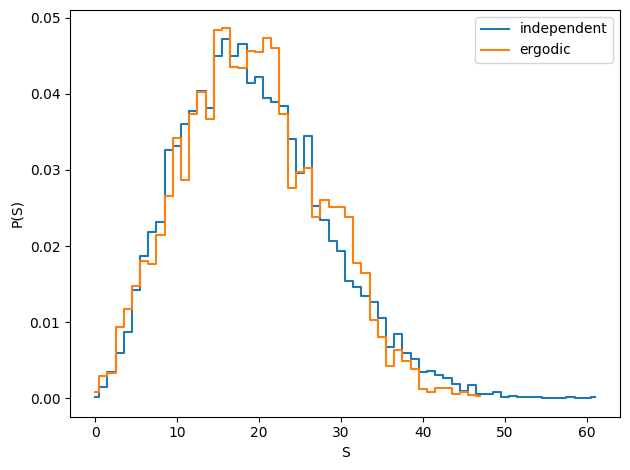

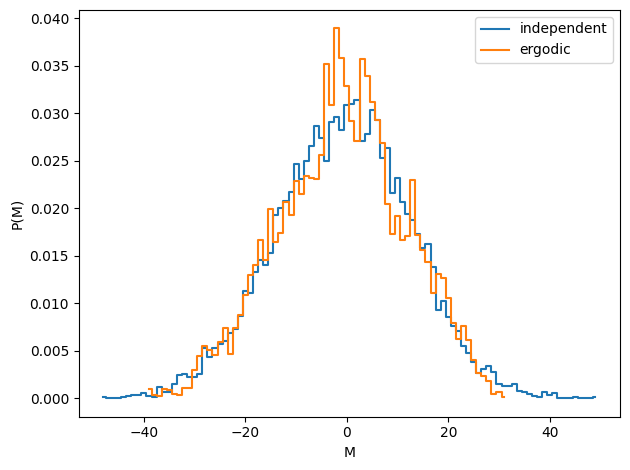

In [2]:
include("SuperradiantLasing/scripts/check_stationary_sampling.jl")


Mean stationary sample S = 5.9617
Mean stationary sample M = 

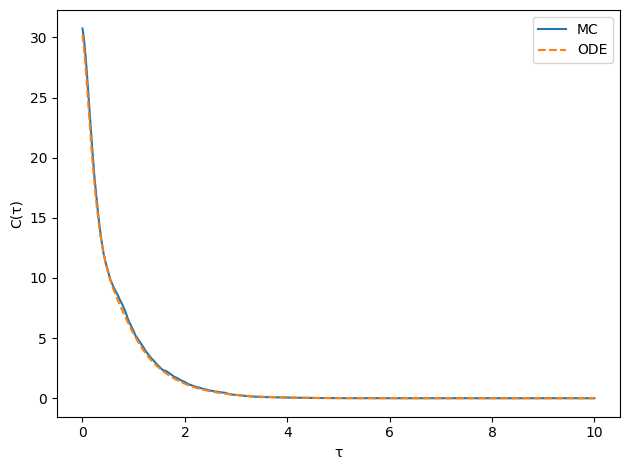

-0.3945


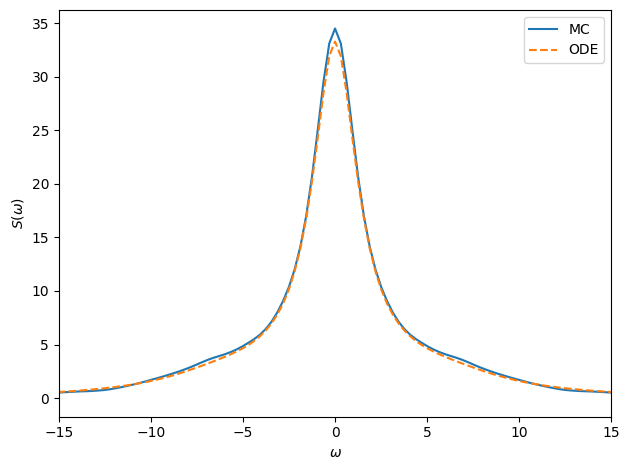

In [3]:
include("SuperradiantLasing/scripts/compare_coherence_mc_vs_ode.jl")


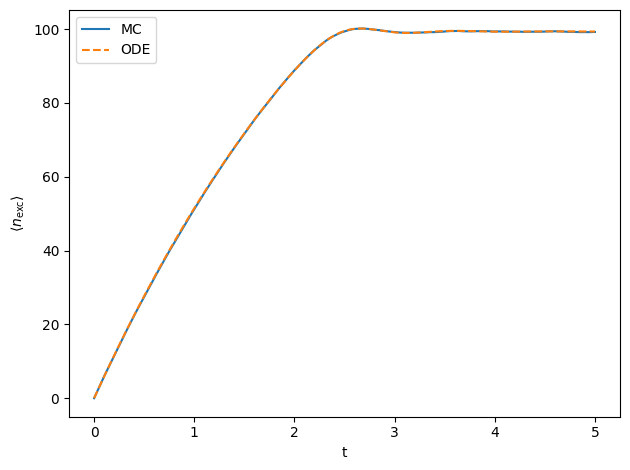

In [4]:
include("SuperradiantLasing/scripts/compare_population_mc_vs_ode.jl")


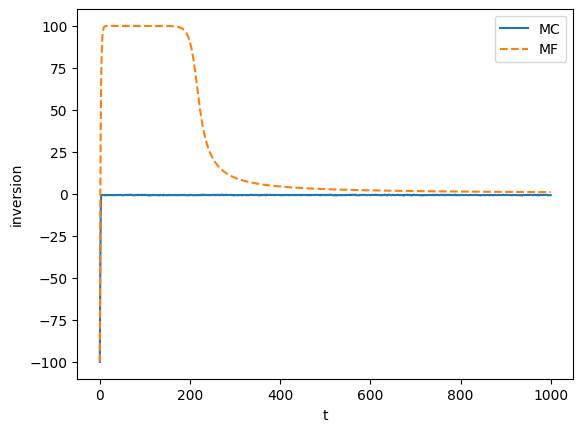

Matched parameters:
  thresholds γp⁻, γp⁺ = (0.0, 200.0)
  lasing regime? true
0.1414213562373095
Matched parameters:
  thresholds γp⁻, γp⁺ = (0.0, 200.0)
  lasing regime? true
  max |Δexc| = 100.90447472783045
  max |ΔM|   = 101.02212620362708


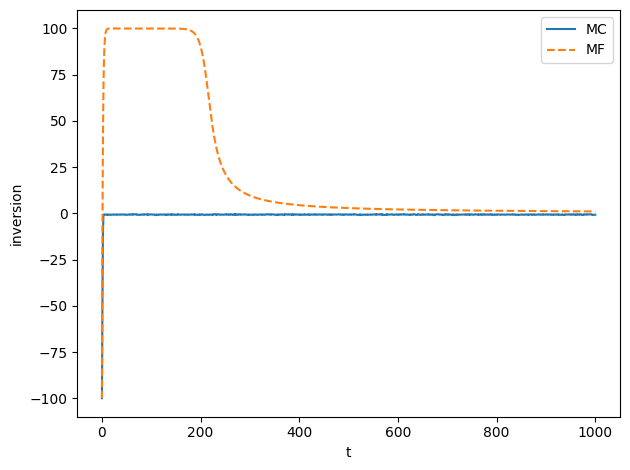

In [5]:
include("SuperradiantLasing/scripts/compare_mc_vs_meanfield.jl")


Mean stationary sample S = 5.9617
Mean stationary sample M = 

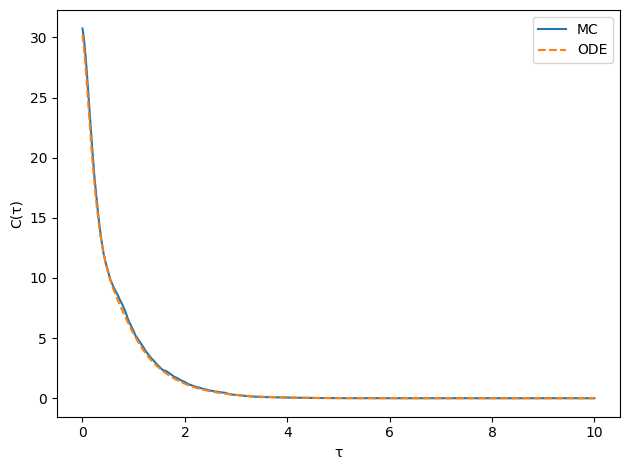

-0.3945


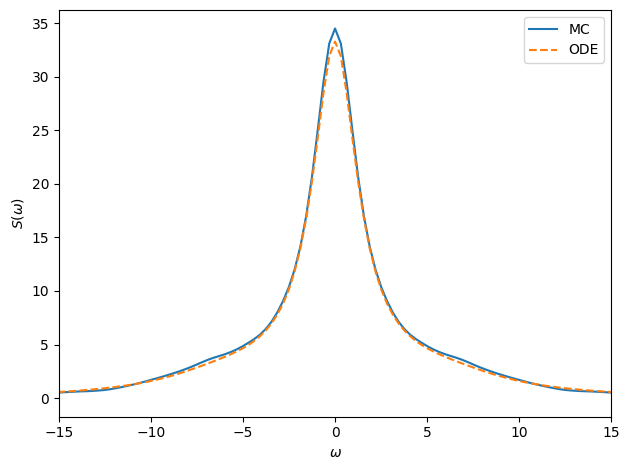

In [6]:
include("SuperradiantLasing/scripts/compare_coherence_mc_vs_ode.jl")

# Monte Carlo and ODE comparison

thresholds = (0.05050506338833394, 19.84949493661167)
inside lasing?  true
outside lasing? true


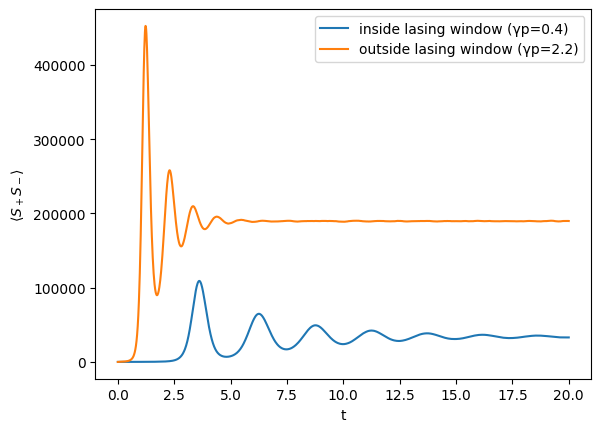

In [9]:
using PyPlot


# MC observable: S_+ S_-
obs_I(S, M, model) = (S + M) * (S - M + 1)

# Choose MF parameters first, then map to MC via Γeff = g^2/κ
N = 2000
g = 0.1
κ = 1.0
γ = 0.05

γp_minus, γp_plus = pump_thresholds(N, g, κ, γ)
println("thresholds = ", (γp_minus, γp_plus))

# one inside, one outside
γp_in  = 0.40
γp_out = 2.20

println("inside lasing?  ", in_lasing_regime(N, g, κ, γ, γp_in))
println("outside lasing? ", in_lasing_regime(N, g, κ, γ, γp_out))

Γeff = g^2 / κ

model_in = PopulationModel(
    N,
    N ÷ 2,
    Γeff,    # global_decay
    0.0,     # global_pump
    γ,       # local_decay = spontaneous emission
    γp_in,   # local_pump
    0.0,     # local_dephasing
)

model_out = PopulationModel(
    N,
    N ÷ 2,
    Γeff,
    0.0,
    γ,
    γp_out,
    0.0,
)

N_traj = 8000
t_max = 20.0
n_grid = 1500

t_in, I_in = simulate_population_ensemble(
    model_in,
    obs_I,
    N_traj;
    S0 = model_in.Jmax,
    M0 = -model_in.Jmax,
    t_max = t_max,
    n_grid = n_grid,
)

t_out, I_out = simulate_population_ensemble(
    model_out,
    obs_I,
    N_traj;
    S0 = model_out.Jmax,
    M0 = -model_out.Jmax,
    t_max = t_max,
    n_grid = n_grid,
)

figure()
plot(t_in, I_in, label="inside lasing window (γp=$(γp_in))")
plot(t_out, I_out, label="outside lasing window (γp=$(γp_out))")
xlabel("t")
ylabel(L"\langle S_+ S_- \rangle")
legend()
display(gcf())
close("all")

Mean stationary sample S = 5.9617
Mean stationary sample M = 

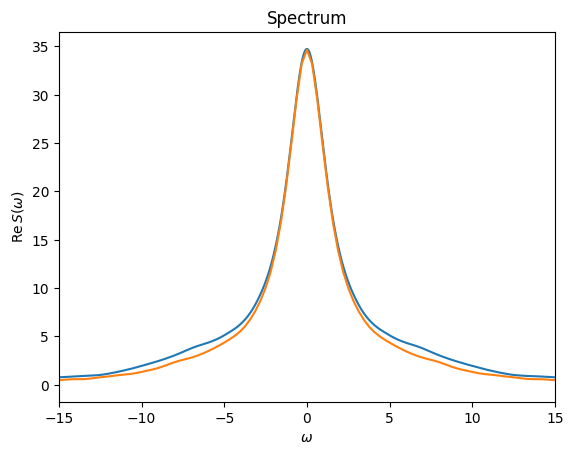

-0.3945


(-15.0, 15.0)

In [11]:

N = 200
N_traj = 10000

pop_model = PopulationModel(
    N,
    N ÷ 2,
    1.0,   # global_decay
    0.0,   # global_pump
    0.0,   # local_decay
    0.3,   # local_pump
    0.0,   # local_dephasing
)

# --------------------------
# 2. Build stationary samples
#    One (S,M) at fixed t_ss from each trajectory
# --------------------------
t_ss = 80.0
rng = Xoshiro(1234)

S_samples, M_samples = get_stationary_population_samples(
    pop_model,
    N_traj;
    t_ss = t_ss,
    S0 = pop_model.Jmax,
    M0 = -pop_model.Jmax,
    rng = rng,
)

println("Mean stationary sample S = ", mean(S_samples))
println("Mean stationary sample M = ", mean(M_samples))

# --------------------------
# 3. Correlator from coherence sector
# --------------------------
coh_model = CoherenceModel(pop_model)

τ_max = 10.0
n_grid = 1200

τ_grid, Cτ = simulate_coherence_correlator_from_samples(
    S_samples,
    M_samples,
    coh_model;
    τ_max = τ_max,
    n_grid = n_grid,
    rng = rng,
)

ω_max = 15.0
n_ω = 1600
ω_grid = collect(range(-ω_max, ω_max, length=n_ω))
Sω = spectrum_from_correlator(τ_grid, Cτ, ω_grid)

figure()
plot(ω_grid, real.(Sω))
xlabel(L"\omega")
ylabel(L"\mathrm{Re}\,S(\omega)")
title("Spectrum")

τ_grid, Cτ = simulate_correlator_ergodic( pop_model; N_traj = N_traj, t_ss = t_ss, τ_max = τ_max,
    n_grid = 1000,
    S0 = pop_model.Jmax,
    M0 = pop_model.Jmax,
    rng = Xoshiro(1234)
)

ω_max = 15.0
n_ω = 1600
ω_grid = collect(range(-ω_max, ω_max, length=n_ω))
ω_grid, Sω = spectrum_even_fft(τ_grid, Cτ)

plot(ω_grid, real.(Sω))
xlabel(L"\omega")
ylabel(L"\mathrm{Re}\,S(\omega)")
title("Spectrum")
xlim(left = -15.0, right = 15.0)

14637.854052564067

14295.121918683079

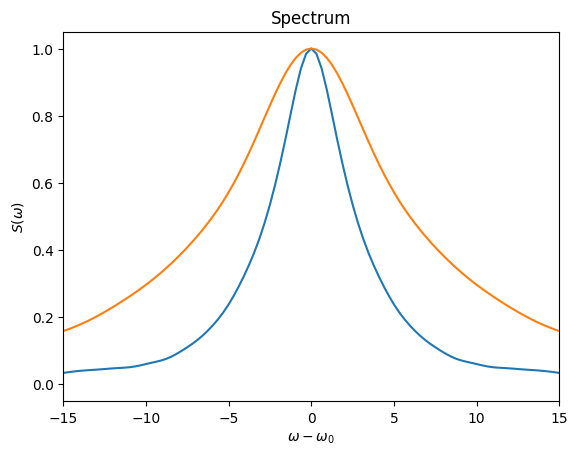

In [12]:

for N in [500, 1000]
    N_traj = 1000
    τ_max = 10.0
    t_ss = 20.0
    r = N - 100.0

    pop_model = PopulationModel(
        N,
        N ÷ 2,
        1.0,   # global_decay
        0.0,   # global_pump
        0.0,   # local_decay
        r,   # local_pump
        0.0,   # local_dephasing
    )

    # --------------------------
    # 5. Convenience wrapper usage
    #    If you want the whole pipeline in one call
    # --------------------------
    τ_grid2, Cτ2, S_samples2, M_samples2 = simulate_correlator_ergodic(
        pop_model;
        N_traj = N_traj,
        t_ss = t_ss,
        τ_max = τ_max,
        n_grid = n_grid,
        S0 = pop_model.Jmax,
        M0 = -pop_model.Jmax,
        rng = Xoshiro(1234),
    )

    ω_grid, Sω2 = spectrum_even_fft(τ_grid2, Cτ2)
    display(maximum(Sω2))

    plot(ω_grid, Sω2 ./ maximum(Sω2), label = "\$N=$N\$")
    xlabel(L"\omega-\omega_0")
    ylabel(L"S(\omega)")
    title("Spectrum")
end

xlim(left = -15.0, right = 15.0)
display(gcf())
close("all")

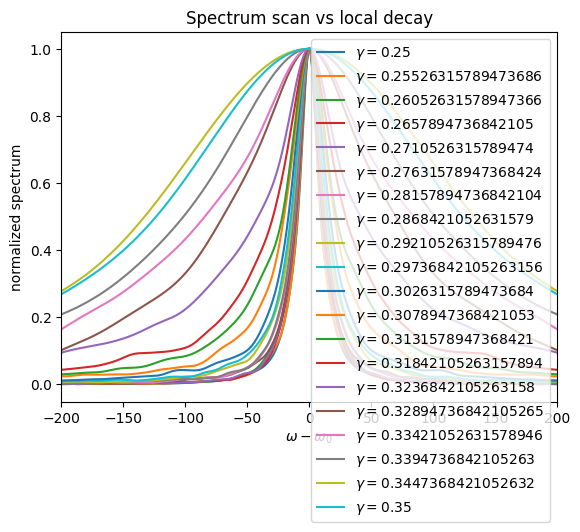

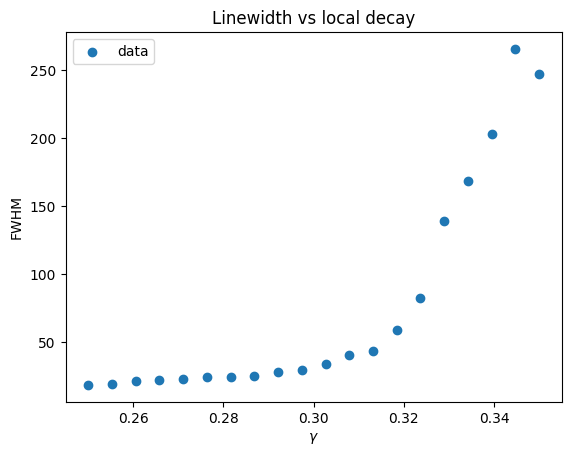

LoadError: UndefVarError: `ω_grid` not defined in `Main.SuperradiantLasing`
Suggestion: check for spelling errors or missing imports.

In [13]:
out = scan_gamma_linewidth(
    range(0.25, 0.35, 20);
    N = 4000,
    N_traj = 4000,
    τ_max = 10.0,
    t_ss = 20.0,
    n_grid = 2000,
    ω_max = 200.0,
    n_ω = 4000,
    pump = 0.3,
    Γ = 1.0,
    deph = 0.0,
    seed = 1234,
)